In [25]:
# ==========================================
# SETUP & THEME INITIALIZATION
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the pre-cleaned data directly
df = pd.read_csv('cleaned_master_dataset.csv')
print(f"Data loaded! Shape: {df.shape}")

# Presentation-quality visual settings
CUSTOM_PALETTE = ['#2B5B84', '#F4A261', '#E76F51', '#2A9D8F', '#E9C46A', '#6A4C93']
sns.set_palette(CUSTOM_PALETTE)
plt.rcParams.update({
    'figure.dpi': 150, 
    'figure.figsize': (10, 6), 
    'axes.spines.top': False, 
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlepad': 15
})

print("Phase 2 Initialized: Diagnostic & Prescriptive Analytics...")

Data loaded! Shape: (714669, 91)
Phase 2 Initialized: Diagnostic & Prescriptive Analytics...


1. DIAGNOSTIC: Price Elasticity & Cannibalization Analysis...



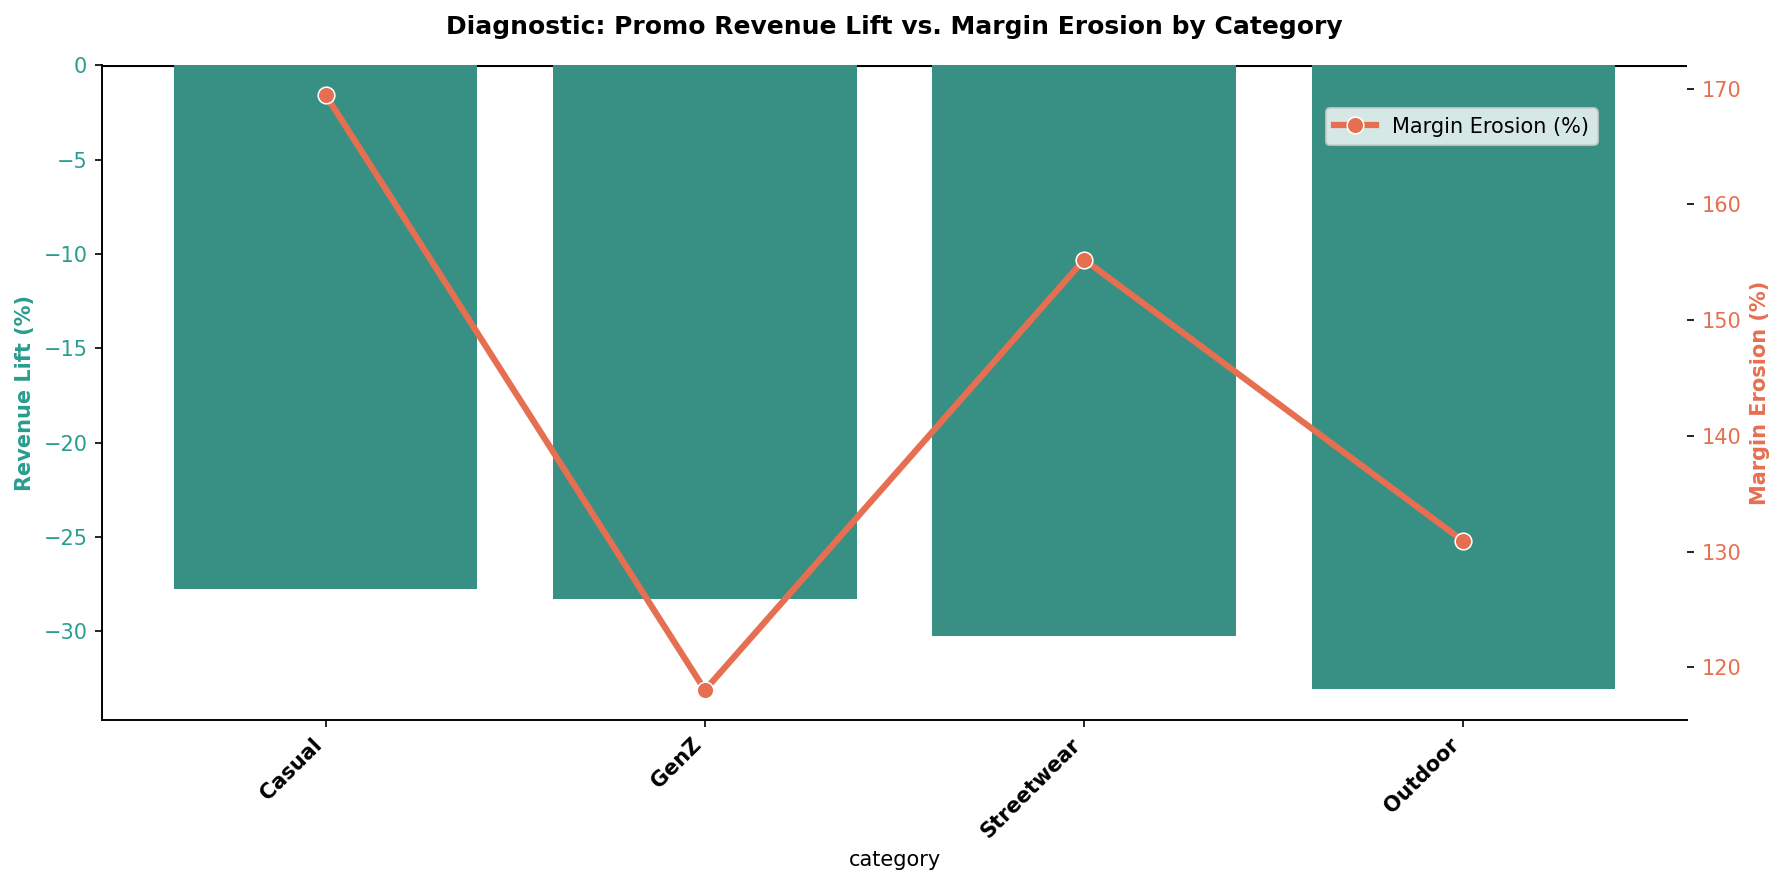

In [26]:
# ==========================================
# PROMO IMPACT & CANNIBALIZATION
# ==========================================
print("1. DIAGNOSTIC: Price Elasticity & Cannibalization Analysis...\n")

# Calculate metrics during Promo vs Non-Promo periods by Category
promo_impact = df.groupby(['category', 'has_promo']).agg(
    Avg_Daily_Revenue=('Net_Revenue', 'mean'),
    Avg_Margin=('Gross_Profit', 'mean'),
    Total_Units=('quantity', 'sum')
).unstack()

# Flatten multi-index columns
promo_impact.columns = ['_'.join(map(str, col)).strip() for col in promo_impact.columns.values]

# Fill NaNs if some categories never had a promo
promo_impact = promo_impact.fillna(0)

# Calculate Lift and Margin Erosion
if 'Avg_Daily_Revenue_1' in promo_impact.columns and 'Avg_Daily_Revenue_0' in promo_impact.columns:
    promo_impact['Revenue_Lift_Pct'] = ((promo_impact['Avg_Daily_Revenue_1'] - promo_impact['Avg_Daily_Revenue_0']) / promo_impact['Avg_Daily_Revenue_0']) * 100
    promo_impact['Margin_Erosion_Pct'] = ((promo_impact['Avg_Margin_0'] - promo_impact['Avg_Margin_1']) / promo_impact['Avg_Margin_0']) * 100

    # Sort by highest Revenue Lift
    promo_impact = promo_impact.sort_values('Revenue_Lift_Pct', ascending=False)

# Visualization
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Add a horizontal Zero Line to ground the negative bars
    ax1.axhline(0, color='black', linewidth=1.5, zorder=0)

    sns.barplot(x=promo_impact.index, y=promo_impact['Revenue_Lift_Pct'],
                hue=promo_impact.index, palette=['#2A9D8F']*len(promo_impact),
                legend=False, ax=ax1, zorder=3)
    
    ax1.set_ylabel('Revenue Lift (%)', color='#2A9D8F', fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='#2A9D8F')

    # Rotate the x-axis labels so we can actually read them!
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontweight='bold')

    ax2 = ax1.twinx()
    sns.lineplot(x=promo_impact.index, y=promo_impact['Margin_Erosion_Pct'], 
                 color='#E76F51', marker='o', markersize=8, linewidth=3, ax=ax2, label='Margin Erosion (%)')
    
    ax2.set_ylabel('Margin Erosion (%)', color='#E76F51', fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='#E76F51')

    plt.title('Diagnostic: Promo Revenue Lift vs. Margin Erosion by Category')
    
    # Clean up the legend (remove duplicates)
    handles, labels = ax2.get_legend_handles_labels()
    ax2.legend(handles=handles[:1], labels=labels[:1], loc='upper right', bbox_to_anchor=(0.95, 0.95))

    plt.tight_layout() 
    plt.show()

2. DIAGNOSTIC: The Delivery Gap Analysis...



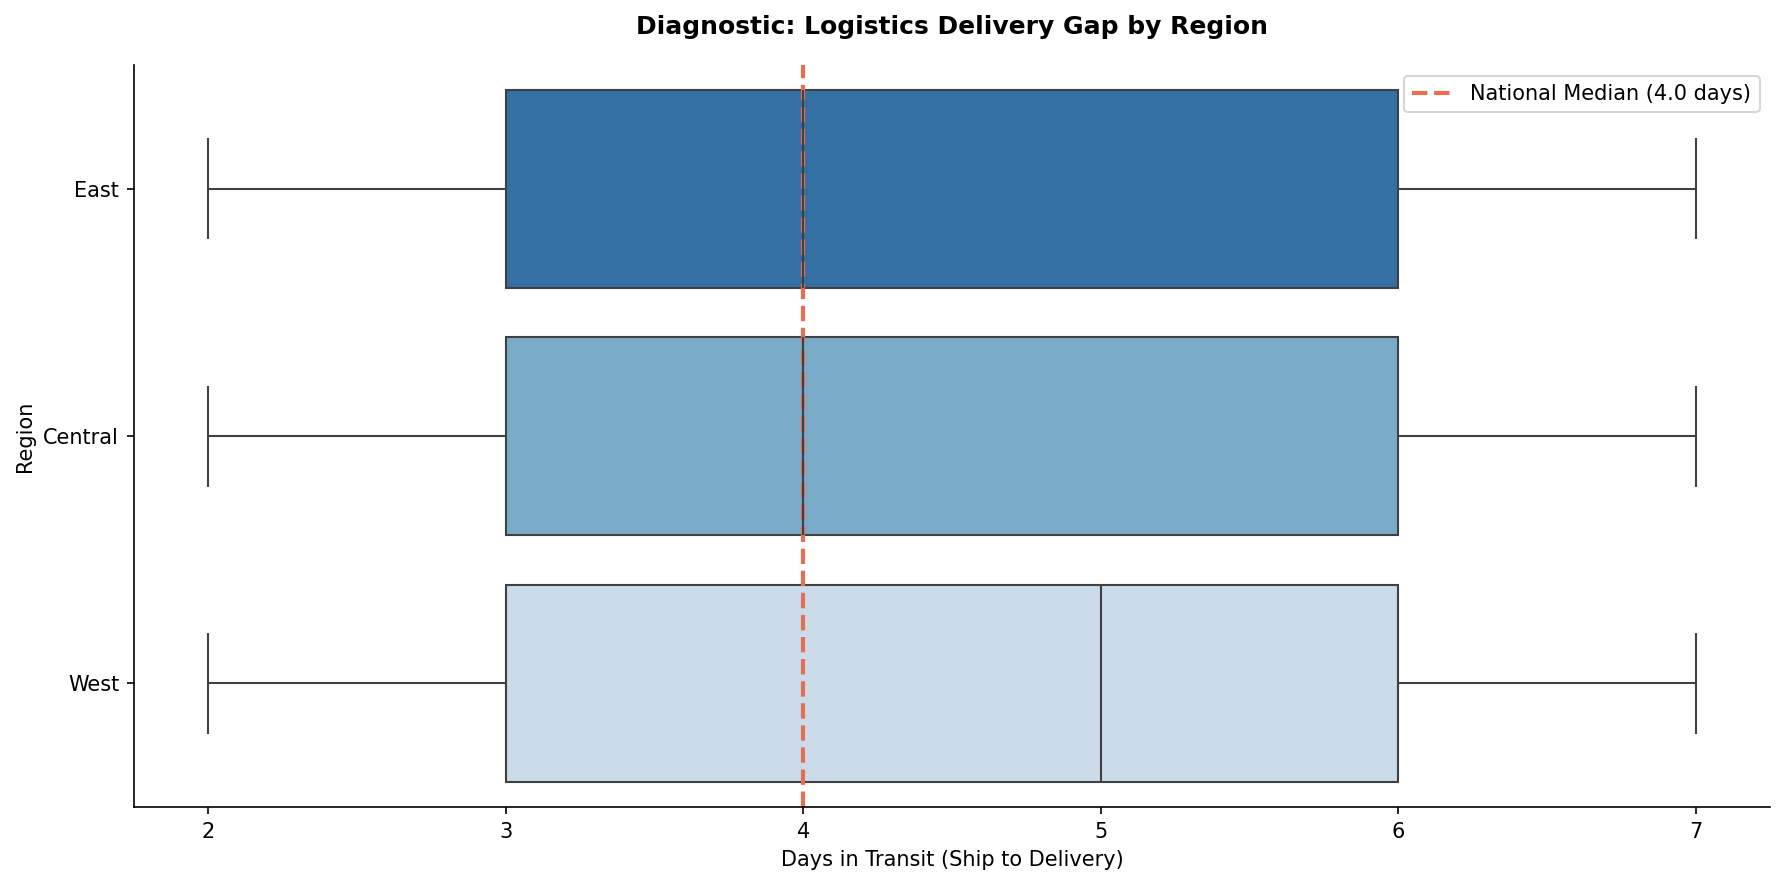

INSIGHT: Regions stretching far to the right of the National Median represent critical supply chain bottlenecks. Customers here are at high risk of churn due to slow fulfillment. Negotiate strict SLAs with regional 3PL carriers.


In [27]:
# ==========================================
# CELL 3: REGIONAL DELIVERY GAP ANALYSIS
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("2. DIAGNOSTIC: The Delivery Gap Analysis...\n")

del_df = df[['order_id', 'ship_date', 'delivery_date', 'region']].drop_duplicates()

# Calculate Transit Days
del_df['transit_days'] = (pd.to_datetime(del_df['delivery_date']) - pd.to_datetime(del_df['ship_date'])).dt.days
del_df = del_df[(del_df['transit_days'] >= 0) & (del_df['transit_days'] <= 30)] # Drop anomalies

# Visualize Boxplot by Region
plt.figure(figsize=(12, 6))
sns.boxplot(data=del_df, x='transit_days', y='region', palette='Blues_r', showfliers=False)
plt.axvline(del_df['transit_days'].median(), color='#E76F51', linestyle='--', linewidth=2, label=f'National Median ({del_df["transit_days"].median()} days)')
plt.title('Diagnostic: Logistics Delivery Gap by Region')
plt.xlabel('Days in Transit (Ship to Delivery)')
plt.ylabel('Region')
plt.legend()
plt.tight_layout()
plt.show()

print("INSIGHT: Regions stretching far to the right of the National Median represent critical supply chain bottlenecks. Customers here are at high risk of churn due to slow fulfillment. Negotiate strict SLAs with regional 3PL carriers.")

3. PRESCRIPTIVE: Zombie Product Index...



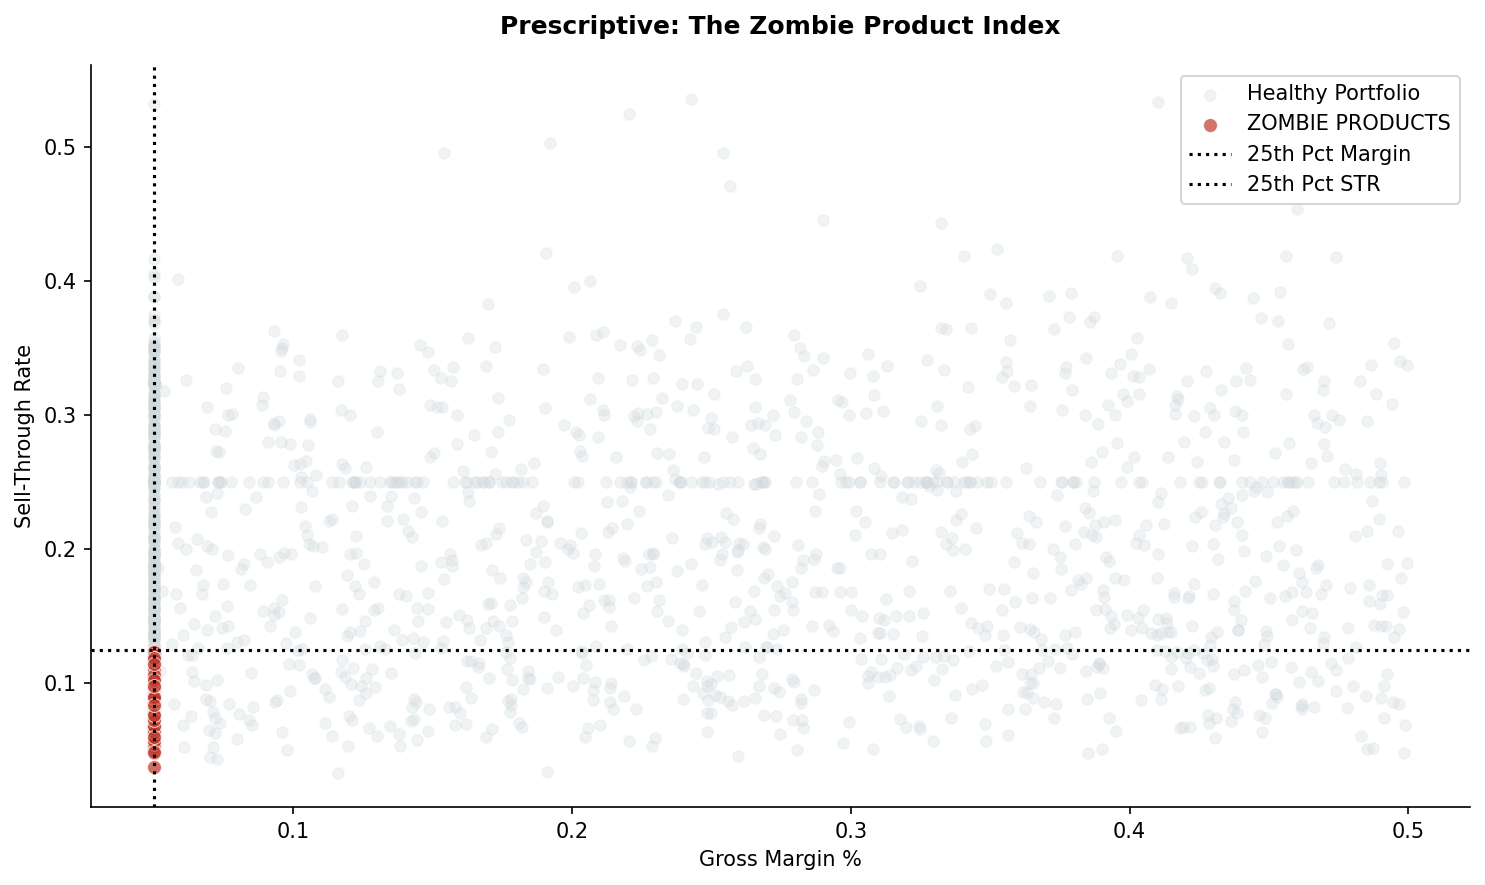

In [28]:
# ==========================================
# ZOMBIE PRODUCT INDEX
# ==========================================
print("3. PRESCRIPTIVE: Zombie Product Index...\n")

inv = pd.read_csv('csv/inventory.csv')
prod = pd.read_csv('csv/products.csv')

prod['margin_pct'] = (prod['price'] - prod['cogs']) / prod['price']

# Aggregate Inventory
inv_agg = inv.groupby('product_id').agg({
    'sell_through_rate': 'mean',
    'stock_on_hand': 'last', 
    'units_sold': 'sum'
}).reset_index()

zombie_df = inv_agg.merge(prod[['product_id', 'product_name', 'category', 'margin_pct']], on='product_id', how='left')

# The 25th Percentile Thresholds
str_thresh = zombie_df['sell_through_rate'].quantile(0.25)
mar_thresh = zombie_df['margin_pct'].quantile(0.25)

# Identify Zombies
zombies = zombie_df[(zombie_df['sell_through_rate'] <= str_thresh) & 
                    (zombie_df['margin_pct'] <= mar_thresh) & 
                    (zombie_df['stock_on_hand'] > 0)]

plt.figure(figsize=(10, 6))

# 1. Healthy Portfolio: Make them smaller and more transparent so they stay in the background
sns.scatterplot(data=zombie_df, x='margin_pct', y='sell_through_rate', 
                color='#cfd8dc', alpha=0.3, s=30, edgecolor=None, label='Healthy Portfolio')

# 2. Zombie Products: 
# - s=45 (smaller dots)
# - alpha=0.7 (slight transparency to show density)
# - edgecolor='white' (adds a tiny border to separate overlapping dots)
sns.scatterplot(data=zombies, x='margin_pct', y='sell_through_rate', 
                color='#c0392b', s=45, alpha=0.7, edgecolor='white', linewidth=0.5, label='ZOMBIE PRODUCTS')

plt.axvline(mar_thresh, color='black', linestyle=':', label='25th Pct Margin')
plt.axhline(str_thresh, color='black', linestyle=':', label='25th Pct STR')

plt.title('Prescriptive: The Zombie Product Index')
plt.xlabel('Gross Margin %')
plt.ylabel('Sell-Through Rate')

plt.legend()
plt.tight_layout()
plt.show()

4. PRESCRIPTIVE: Optimizing Free Shipping Threshold...



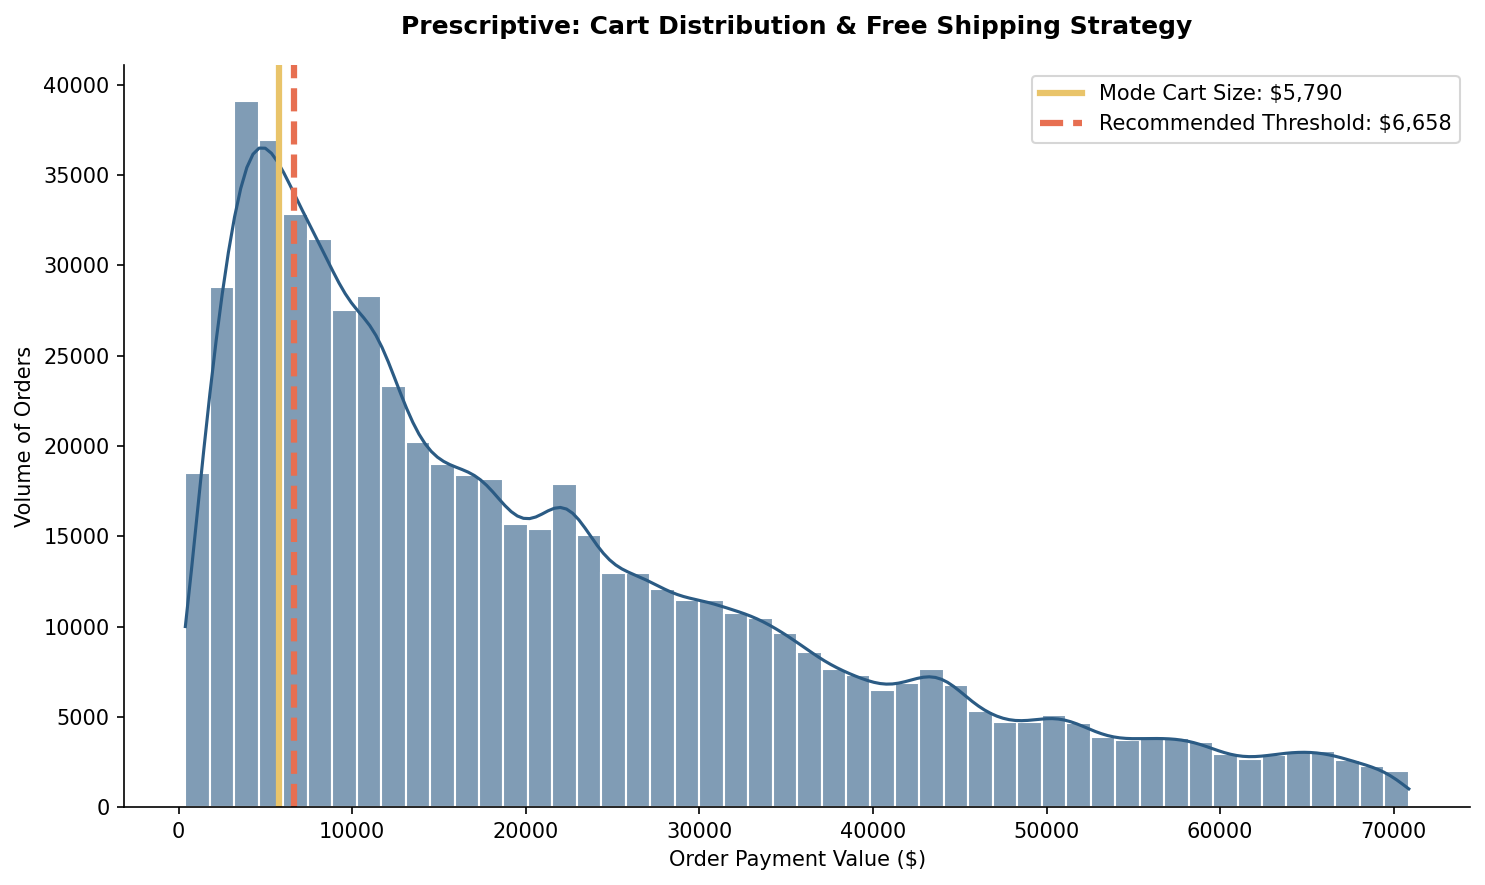

INSIGHT: The most common customer currently spends $5,790.
ACTION: Set the Free Shipping threshold at $6,658. This forces the modal buyer to add one small 'cart-filler' item, covering the logistics cost via incremental product margin.


In [29]:
# ==========================================
# FREE SHIPPING THRESHOLD
# ==========================================
print("4. PRESCRIPTIVE: Optimizing Free Shipping Threshold...\n")

# Load the payments CSV directly from your local folder
pay = pd.read_csv('csv/payments.csv')

# Remove massive B2B outliers (top 5%) to focus entirely on standard consumer behavior
consumer_pay = pay[pay['payment_value'] < pay['payment_value'].quantile(0.95)]

# Find the Mode (Most common cart size) and round it to the nearest $10 for clean business logic
modal_value = consumer_pay['payment_value'].round(-1).mode()[0]

# Define the Stretch Goal (Pushing customers to spend 15% more)
target_upsell = 0.15 
recommended_threshold = modal_value * (1 + target_upsell)

# --- Visualization ---
plt.figure(figsize=(10, 6))

# Plot the distribution
sns.histplot(consumer_pay['payment_value'], bins=50, color='#2B5B84', kde=True, alpha=0.6, edgecolor='white')

# Add vertical insight lines
plt.axvline(modal_value, color='#E9C46A', linestyle='-', linewidth=3, 
            label=f'Mode Cart Size: ${modal_value:,.0f}')
plt.axvline(recommended_threshold, color='#E76F51', linestyle='--', linewidth=3, 
            label=f'Recommended Threshold: ${recommended_threshold:,.0f}')

# Formatting
plt.title('Prescriptive: Cart Distribution & Free Shipping Strategy')
plt.xlabel('Order Payment Value ($)')
plt.ylabel('Volume of Orders')
plt.legend()
plt.tight_layout()
plt.show()

# --- Business Recommendation ---
print(f"INSIGHT: The most common customer currently spends ${modal_value:,.0f}.")
print(f"ACTION: Set the Free Shipping threshold at ${recommended_threshold:,.0f}. "
      f"This forces the modal buyer to add one small 'cart-filler' item, "
      f"covering the logistics cost via incremental product margin.")

5. PRESCRIPTIVE: Capital Efficiency (GMROI) & Reordering...



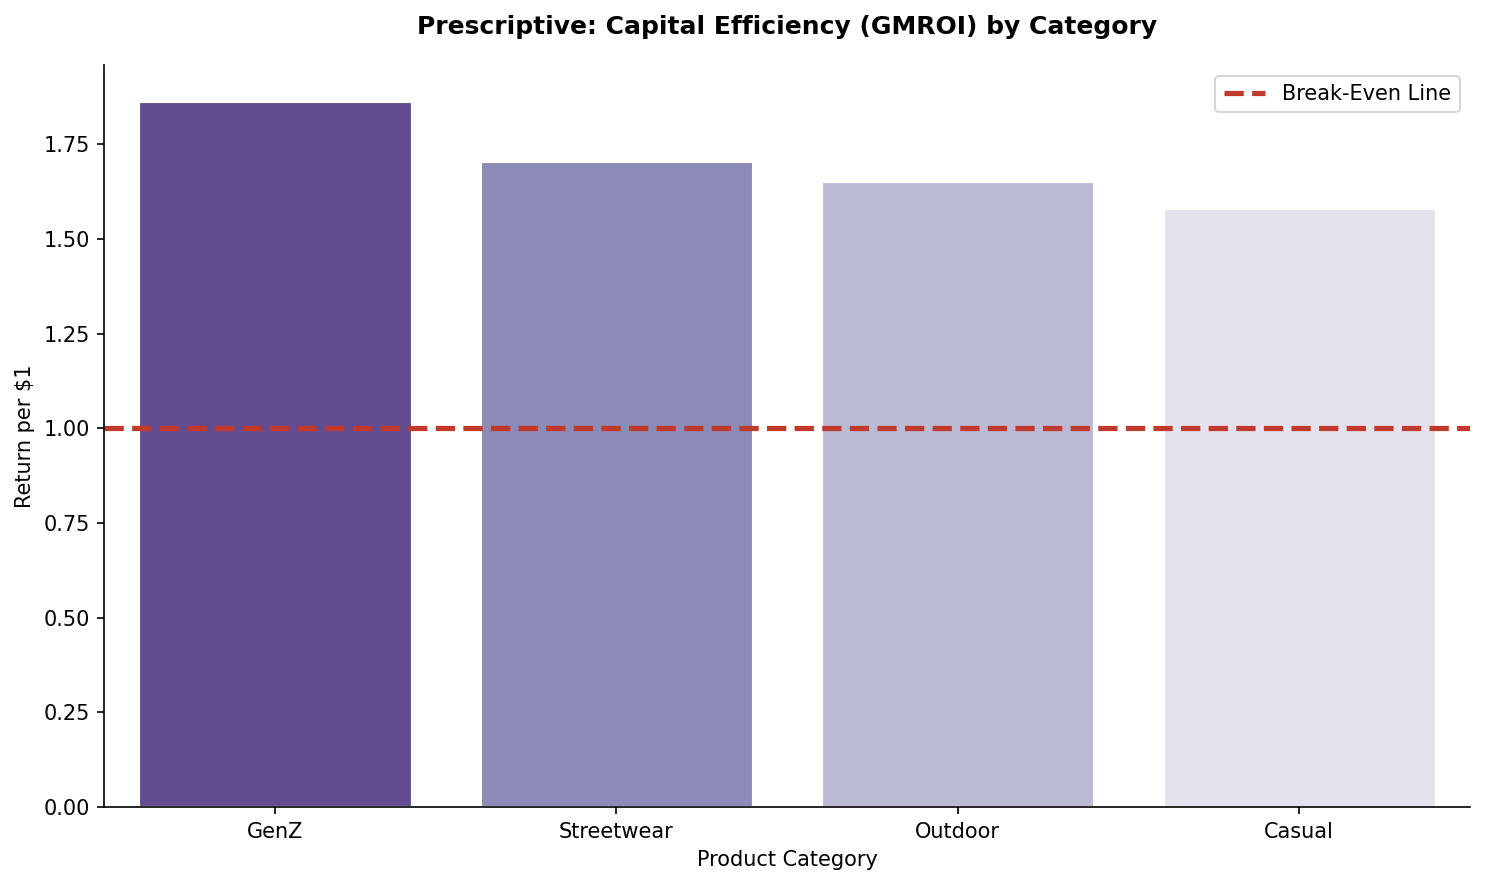

INSIGHT: A GMROI of 1.0 means breaking even. Categories exceeding 2.0 GMROI are highly capital efficient, returning $2+ for every $1 tied up in warehouse stock.
ACTION: Shift open-to-buy purchasing budgets toward these high-GMROI categories. Enforce the calculated 'Reorder Point' logic (Lead Time Demand + Safety Stock) strictly on these items to prevent highly-profitable stockouts.


,GMROI,reorder_point
category,,
GenZ,$1.87,"1,216 units"
Streetwear,$1.71,"14,103 units"
Outdoor,$1.65,"6,991 units"
Casual,$1.58,932 units


In [30]:
# ==========================================
# GMROI & SAFETY STOCK PLANNING
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

print("5. PRESCRIPTIVE: Capital Efficiency (GMROI) & Reordering...\n")

# Load the required CSVs directly from your local folder
inv = pd.read_csv('csv/inventory.csv')
prod = pd.read_csv('csv/products.csv')

# 1. Aggregate Inventory to get current stock, historical demand, AND snapshot count
inv_agg = inv.groupby('product_id').agg({
    'units_sold': 'sum',
    'stock_on_hand': 'last',
    'snapshot_date': 'count'  # ← THE FIX: count = number of monthly snapshots
}).reset_index().rename(columns={'snapshot_date': 'n_months'})

# Merge with Products to get Financials (Price and COGS)
plan_df = inv_agg.merge(prod[['product_id', 'category', 'price', 'cogs']], on='product_id', how='inner')

# 2. GMROI Calculation (Gross Margin / Average Inventory Cost)
plan_df['margin_dollars'] = (plan_df['price'] - plan_df['cogs']) * plan_df['units_sold']
plan_df['inventory_cost'] = plan_df['stock_on_hand'] * plan_df['cogs']

# Safely divide, avoiding ZeroDivisionError for out-of-stock items
plan_df['GMROI'] = np.where(plan_df['inventory_cost'] > 0, 
                            plan_df['margin_dollars'] / plan_df['inventory_cost'], 0)

# 3. Safety Stock & Reorder Point Formulation
# BUSINESS ASSUMPTION: 30-Day Inbound Supplier Lead Time
LEAD_TIME_DAYS = 30

# THE FIX: Calculate true daily demand based on the actual number of months tracked
plan_df['daily_demand'] = plan_df['units_sold'] / (plan_df['n_months'] * 30).clip(lower=1)

# Safety Stock = Demand * (Lead Time * 0.5 Variance Buffer)
plan_df['safety_stock'] = plan_df['daily_demand'] * (LEAD_TIME_DAYS * 0.5) 

# Reorder Point = Expected Lead Time Demand + Safety Stock
plan_df['reorder_point'] = np.ceil((plan_df['daily_demand'] * LEAD_TIME_DAYS) + plan_df['safety_stock'])

# 4. Aggregate by Category for the C-Suite view
cat_gmroi = plan_df.groupby('category').agg({
    'GMROI': 'mean',
    'reorder_point': 'sum'
}).sort_values(by='GMROI', ascending=False)

# --- Visualization ---
plt.figure(figsize=(10, 6))

sns.barplot(x=cat_gmroi.index, y=cat_gmroi['GMROI'], palette='Purples_r', edgecolor='white', linewidth=1.5)

# The critical Breakeven line (1.0 means we just made our money back)
plt.axhline(1.0, color='#c0392b', linestyle='--', linewidth=2.5, label='Break-Even Line')

plt.title('Prescriptive: Capital Efficiency (GMROI) by Category')
plt.ylabel('Return per $1')
plt.xlabel('Product Category')
plt.legend()
plt.tight_layout()
plt.show()

# --- Business Recommendation ---
print("INSIGHT: A GMROI of 1.0 means breaking even. Categories exceeding 2.0 GMROI are highly capital efficient, returning $2+ for every $1 tied up in warehouse stock.")
print("ACTION: Shift open-to-buy purchasing budgets toward these high-GMROI categories. Enforce the calculated 'Reorder Point' logic (Lead Time Demand + Safety Stock) strictly on these items to prevent highly-profitable stockouts.")
display(cat_gmroi.style.format({'GMROI': '${:.2f}', 'reorder_point': '{:,.0f} units'}))

6. PRESCRIPTIVE: Yield Management Targets (Discount Optimization)...



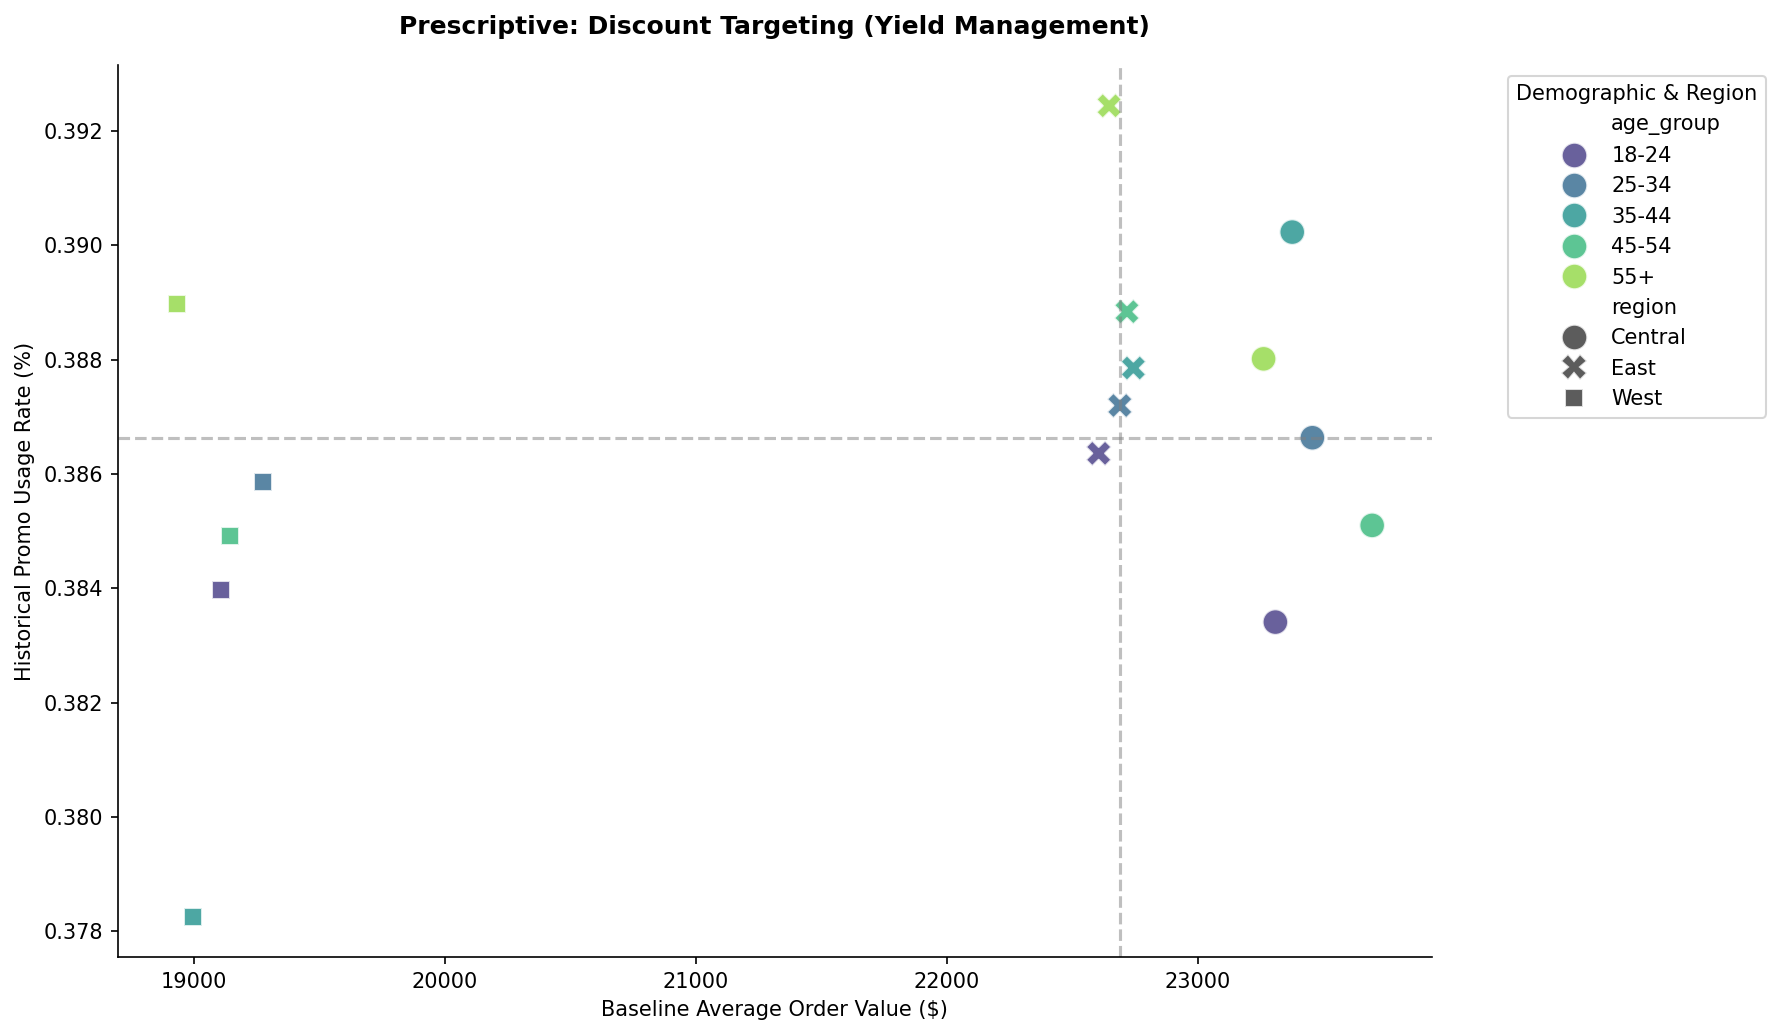

INSIGHT: The chart is divided into 4 quadrants. Segments in the Top-Left (High Promo Usage, Low Baseline Spend) are highly price-sensitive.
ACTION: Launch targeted, segment-specific email campaigns. ONLY send discount codes to the Top-Left segments to drive conversion. Withhold promotions from Bottom-Right segments, as our data proves they are inelastic and will purchase at full price anyway.

--- TOP 5 DISCOUNT-RELIANT SEGMENTS ---


,age_group,region,Promo_Usage_Rate,Avg_Order_Value
14,55+,West,38.9%,$18934.49
11,45-54,West,38.5%,$19142.98
2,18-24,West,38.4%,$19108.80
5,25-34,West,38.6%,$19275.98
8,35-44,West,37.8%,$18997.06


In [31]:
# ==========================================
# YIELD MANAGEMENT & SEGMENTATION
# ==========================================

print("6. PRESCRIPTIVE: Yield Management Targets (Discount Optimization)...\n")

# Use the Master Dataset (df) which already has customer age and geography merged in Cell 1
# Drop unknown or missing age groups for a cleaner business analysis
yield_df = df[df['age_group'] != 'Unknown'].copy()

# Aggregate by Demographic and Region
segment_behavior = yield_df.groupby(['age_group', 'region']).agg(
    Total_Revenue=('Net_Revenue', 'sum'),
    Promo_Usage_Rate=('has_promo', 'mean'), # % of orders that used a discount
    Avg_Order_Value=('line_revenue', 'mean')
).reset_index()

# Target Score Math: High Promo Usage / Low AOV = Highly Price Sensitive
segment_behavior['Target_Score'] = segment_behavior['Promo_Usage_Rate'] / segment_behavior['Avg_Order_Value']

# Sort to find the most price-sensitive segments
top_targets = segment_behavior.sort_values('Target_Score', ascending=False).head(5)

# --- Visualization ---
plt.figure(figsize=(12, 7))

# Scatterplot showing the four quadrants of customer behavior
sns.scatterplot(
    data=segment_behavior, 
    x='Avg_Order_Value', 
    y='Promo_Usage_Rate', 
    hue='age_group', 
    style='region',
    s=150, 
    palette='viridis', 
    alpha=0.8,
    edgecolor='white'
)

# Add quadrant lines (Medians)
plt.axvline(segment_behavior['Avg_Order_Value'].median(), color='grey', linestyle='--', alpha=0.5)
plt.axhline(segment_behavior['Promo_Usage_Rate'].median(), color='grey', linestyle='--', alpha=0.5)

plt.title('Prescriptive: Discount Targeting (Yield Management)')
plt.xlabel('Baseline Average Order Value ($)')
plt.ylabel('Historical Promo Usage Rate (%)')

plt.legend(title='Demographic & Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- Business Recommendation ---
print("INSIGHT: The chart is divided into 4 quadrants. Segments in the Top-Left (High Promo Usage, Low Baseline Spend) are highly price-sensitive.")
print("ACTION: Launch targeted, segment-specific email campaigns. ONLY send discount codes to the Top-Left segments to drive conversion. Withhold promotions from Bottom-Right segments, as our data proves they are inelastic and will purchase at full price anyway.")
print("\n--- TOP 5 DISCOUNT-RELIANT SEGMENTS ---")
display(top_targets[['age_group', 'region', 'Promo_Usage_Rate', 'Avg_Order_Value']].style.format({
    'Promo_Usage_Rate': '{:.1%}', 
    'Avg_Order_Value': '${:.2f}'
}))

In [32]:
# ==========================================
# ML DATASET PREP — SETUP & LOADING
# ==========================================
import os

print("="*65)
print("  DATA ENGINEERING: BUILDING ML MATRICES")
print("="*65)

# THE FIX: Load all 12 tables so subsequent ML cells have access to reviews, returns, etc.
files_to_load = [
    'orders', 'order_items', 'products', 'customers', 
    'inventory', 'promotions', 'returns', 'reviews', 
    'geography', 'payments', 'shipments', 'web_traffic'
]

tables = {}

print("Loading CSV files into memory...")
for name in files_to_load:
    path = f'csv/{name}.csv'
    if os.path.exists(path):
        tables[name] = pd.read_csv(path)
        print(f"  ✓ {name}.csv loaded.")
    else:
        print(f"  ❌ WARNING: {path} not found!")

print("\n All Base Data Loaded. Proceeding to Granularity Splits.")

  DATA ENGINEERING: BUILDING ML MATRICES
Loading CSV files into memory...
  ✓ orders.csv loaded.
  ✓ order_items.csv loaded.
  ✓ products.csv loaded.
  ✓ customers.csv loaded.
  ✓ inventory.csv loaded.
  ✓ promotions.csv loaded.
  ✓ returns.csv loaded.
  ✓ reviews.csv loaded.
  ✓ geography.csv loaded.
  ✓ payments.csv loaded.
  ✓ shipments.csv loaded.
  ✓ web_traffic.csv loaded.

 All Base Data Loaded. Proceeding to Granularity Splits.


In [33]:
# ==========================================
# ML DATASET 1 — DAILY TIME-SERIES 
# ==========================================
print("Building Dataset A: Daily Time-Series (Revenue Forecasting)...")

orders = tables['orders'].copy()
items = tables['order_items'].copy()
products = tables['products'].copy()

# 1. Merge cơ bản để lấy thông tin ngày tháng và COGS (Giá vốn)
df_ts = items.merge(orders[['order_id', 'order_date', 'order_status']], on='order_id', how='inner')
df_ts = df_ts.merge(products[['product_id', 'cogs']], on='product_id', how='left')

# Đưa order_date về định dạng chuẩn (chỉ lấy phần Ngày, bỏ phần Giờ)
df_ts['order_date'] = pd.to_datetime(df_ts['order_date']).dt.date

# 2. Tính Revenue và Profit cho từng dòng
df_ts['line_revenue'] = (df_ts['quantity'] * df_ts['unit_price']) - df_ts['discount_amount'].fillna(0)
df_ts['line_profit'] = df_ts['line_revenue'] - (df_ts['quantity'] * df_ts['cogs'].fillna(0))

# 3. Group by theo Từng Ngày
ts_daily = df_ts.groupby('order_date').agg(
    Daily_Revenue=('line_revenue', 'sum'),
    Actual_Profit=('line_profit', 'sum'), # Tính lợi nhuận để làm Feature quá khứ
    Total_Units_Sold=('quantity', 'sum'),
    Total_Orders=('order_id', 'nunique'),
    Active_Promos=('promo_id', lambda x: x.notna().sum())
).reset_index()

# Đổi lại sang datetime để trích xuất Calendar
ts_daily['order_date'] = pd.to_datetime(ts_daily['order_date'])
ts_daily = ts_daily.sort_values('order_date')

# ---------------------------------------------------------
# TIME-SERIES FEATURE ENGINEERING 
# ---------------------------------------------------------

# A. Calendar Features
ts_daily['Day_of_Week'] = ts_daily['order_date'].dt.dayofweek
ts_daily['Month'] = ts_daily['order_date'].dt.month
ts_daily['Is_Weekend'] = (ts_daily['Day_of_Week'] >= 5).astype(int)

# B. Lags & Rolling (Nhìn về quá khứ)
ts_daily['Revenue_Lag_1D'] = ts_daily['Daily_Revenue'].shift(1)
ts_daily['Revenue_Lag_7D'] = ts_daily['Daily_Revenue'].shift(7)
ts_daily['Revenue_Rolling_7D_Avg'] = ts_daily['Daily_Revenue'].rolling(window=7).mean()

ts_daily['Profit_Lag_7D'] = ts_daily['Actual_Profit'].shift(7)

# C. Tích hợp Refunds (Hoàn tiền) nếu có bảng returns
if 'returns' in tables:
    ret = tables['returns'].copy()
    ret['return_date'] = pd.to_datetime(ret['return_date']).dt.date
    daily_refunds = ret.groupby('return_date').agg(total_refunds=('refund_amount', 'sum')).reset_index()
    daily_refunds['return_date'] = pd.to_datetime(daily_refunds['return_date'])
    
    # Merge vào ts_daily
    ts_daily = ts_daily.merge(daily_refunds, left_on='order_date', right_on='return_date', how='left')
    ts_daily['total_refunds'] = ts_daily['total_refunds'].fillna(0)
    
    ts_daily['Refunds_Lag_7D'] = ts_daily['total_refunds'].shift(7)
else:
    # Nếu không có bảng returns, ta tạo cột giả định bằng 0 để code không văng lỗi
    ts_daily['total_refunds'] = 0 
    ts_daily['Refunds_Lag_7D'] = 0

# D. FIX YOY_GROWTH_REF: Tăng trưởng cùng kỳ
# Dịch đúng 364 ngày (52 tuần x 7 ngày) để so sánh thứ Hai năm nay với thứ Hai năm ngoái
ts_daily['yoy_growth_ref'] = ts_daily['Daily_Revenue'].shift(364)

# Xóa bỏ lợi nhuận và hoàn tiền của "ngày hôm nay". Thuật toán chỉ được phép nhìn thấy Profit/Refund của 7 ngày trước.
leakage_cols = ['Actual_Profit', 'total_refunds', 'return_date']
ts_daily = ts_daily.drop(columns=[c for c in leakage_cols if c in ts_daily.columns])

# Drop tất cả các dòng bị NaN do quá trình Shift (đặc biệt là 364 ngày đầu tiên của lịch sử)
ts_daily = ts_daily.dropna().reset_index(drop=True)

print(f"Time-Series Dataset Ready! Shape: {ts_daily.shape}")
display(ts_daily.head(3))

Building Dataset A: Daily Time-Series (Revenue Forecasting)...
Time-Series Dataset Ready! Shape: (3469, 14)


,order_date,Daily_Revenue,Total_Units_Sold,Total_Orders,Active_Promos,Day_of_Week,Month,Is_Weekend,Revenue_Lag_1D,Revenue_Lag_7D,Revenue_Rolling_7D_Avg,Profit_Lag_7D,Refunds_Lag_7D,yoy_growth_ref
0,2013-07-03,6591718.12,1866,369,412,2,7,0,5911486.88,7517424.69,6.156977e+06,-7.727700e+05,230433.24,5123547.94
1,2013-07-04,2067478.69,483,93,102,3,7,0,6591718.12,6353523.76,5.544685e+06,-1.109292e+06,158377.61,2751773.45
2,2013-07-05,2045168.29,553,108,117,4,7,0,2067478.69,5153990.54,5.100567e+06,-8.894946e+05,304089.35,3054029.42


In [34]:
# ══════════════════════════════════════════════════════════════════
# ML DATASET 2 — CUSTOMER PROPENSITY 
# ══════════════════════════════════════════════════════════════════
print("\nBuilding Dataset B: Customer Level (RFM & Propensity)...")

cust    = tables['customers'].copy()
orders  = tables['orders'].copy()
items   = tables['order_items'].copy()
reviews = tables['reviews'].copy()
ret     = tables['returns'].copy()
geo     = tables['geography'].copy()

orders['order_date'] = pd.to_datetime(orders['order_date'])
items['line_revenue'] = (items['quantity'] * items['unit_price']) - items['discount_amount'].fillna(0)

df_cust = items.merge(orders[['order_id','customer_id','order_date']], on='order_id', how='inner')

SNAPSHOT_DATE = pd.to_datetime('2021-12-31')
history = df_cust[df_cust['order_date'] <= SNAPSHOT_DATE]
future  = df_cust[df_cust['order_date'] >  SNAPSHOT_DATE]

# RFM
rfm = (history.groupby('customer_id')
               .agg(Recency_Days=('order_date',   lambda x: (SNAPSHOT_DATE - x.max()).days),
                    Frequency   =('order_id',      'nunique'),
                    Monetary    =('line_revenue',  'sum'),
                    Avg_Order_Value=('line_revenue','mean'))
               .reset_index())

# Targets
future_buyers = set(future['customer_id'].unique())
future_spend  = future.groupby('customer_id')['line_revenue'].sum().reset_index()
future_spend.columns = ['customer_id', 'Total_Spend_In_2022']

rfm['TARGET_Bought_in_2022'] = rfm['customer_id'].isin(future_buyers).astype(int)
rfm = rfm.merge(future_spend, on='customer_id', how='left')
rfm['Total_Spend_In_2022'] = rfm['Total_Spend_In_2022'].fillna(0)

# Avg review rating per customer
rev_agg = (reviews.groupby('customer_id')['rating']
                   .mean().reset_index()
                   .rename(columns={'rating': 'Avg_Review_Rating'}))  # ← ADDED
rfm = rfm.merge(rev_agg, on='customer_id', how='left')
rfm['Avg_Review_Rating'] = rfm['Avg_Review_Rating'].fillna(rfm['Avg_Review_Rating'].median())

# Return rate per customer
ret_orders = ret.merge(orders[['order_id','customer_id']], on='order_id', how='left')
ret_rate   = (ret_orders.groupby('customer_id')['return_quantity']
                         .sum().reset_index()
                         .rename(columns={'return_quantity': 'Total_Returns'}))  # ← ADDED
rfm = rfm.merge(ret_rate, on='customer_id', how='left')
rfm['Total_Returns'] = rfm['Total_Returns'].fillna(0)
rfm['Return_Rate']   = (rfm['Total_Returns'] / rfm['Frequency'].clip(lower=1)).round(4)

# Demographics
cust_geo = cust.merge(geo[['zip','region']], on='zip', how='left')
rfm = rfm.merge(cust_geo[['customer_id','age_group','gender',
                           'acquisition_channel','region']], on='customer_id', how='left')

# Target encode region and acquisition_channel (mean monetary per group)
for col in ['region', 'acquisition_channel']:               # ← ADDED acquisition_channel
    enc = rfm.groupby(col)['Monetary'].mean().rename(f'{col}_enc')
    rfm = rfm.merge(enc, on=col, how='left')

# One-hot encode remaining categoricals
ml_customer = pd.get_dummies(rfm, columns=['age_group','gender'], drop_first=True)
ml_customer = ml_customer.drop(columns=['region','acquisition_channel'], errors='ignore')

print(f"Customer ML Dataset Ready! Shape: {ml_customer.shape}")
display(ml_customer.head(3))


Building Dataset B: Customer Level (RFM & Propensity)...
Customer ML Dataset Ready! Shape: (88924, 18)


,customer_id,Recency_Days,Frequency,Monetary,Avg_Order_Value,TARGET_Bought_in_2022,Total_Spend_In_2022,Avg_Review_Rating,Total_Returns,Return_Rate,region_enc,acquisition_channel_enc,age_group_25-34,age_group_35-44,age_group_45-54,age_group_55+,gender_Male,gender_Non-binary
0,1,251,6,142803.47,20400.495714,0,0.00,4.0,1.0,0.1667,153272.075365,165216.027068,False,True,False,False,False,False
1,2,2605,3,144697.34,48232.446667,1,59996.55,2.0,0.0,0.0000,153272.075365,162832.339646,False,False,True,False,False,False
2,3,3077,3,52093.47,17364.490000,0,0.00,5.0,0.0,0.0000,153272.075365,164673.739860,False,False,False,False,False,False


In [35]:
# ==========================================
# ML DATASET 3 — PRODUCT INVENTORY RISK
# ==========================================
print("\nBuilding Dataset C: Product Level (Stockout Risk)...")

prod = tables['products'].copy()
inv = tables['inventory'].copy()

inv_hist = (inv.groupby('product_id')
               .agg(avg_monthly_units_sold=('units_sold',    'mean'),
                    last_stock_on_hand     =('stock_on_hand', 'last'),
                    avg_fill_rate          =('fill_rate',     'mean'),
                    avg_sell_through       =('sell_through_rate','mean'),
                    avg_stockout_days      =('stockout_days', 'mean'))
               .reset_index())

# Merge with products (Keeping Price and COGS as crucial ML features)
ml_product = inv_hist.merge(prod[['product_id','category','price','cogs']], on='product_id', how='inner')

ml_product['Gross_Margin_Pct'] = (ml_product['price'] - ml_product['cogs']) / ml_product['price']
ml_product['Daily_Velocity']   = ml_product['avg_monthly_units_sold'] / 30   # now correct: avg month

# Calculate Days to Stockout
ml_product['Days_To_Stockout'] = np.where(ml_product['Daily_Velocity'] > 0,
                                          ml_product['last_stock_on_hand'] / ml_product['Daily_Velocity'], 999)

# Define Target: Will it stockout in < 30 days? 0 - No, 1 = Yes
ml_product['TARGET_Stockout_Risk_30d'] = (ml_product['Days_To_Stockout'] <= 30).astype(int)

# Standardize the stock column name
ml_product['stock_on_hand'] = ml_product['last_stock_on_hand']

# Safely One-Hot Encode Category
if 'category' in ml_product.columns:
    ml_product = pd.get_dummies(ml_product, columns=['category'], drop_first=True)

cols_to_drop = ['Days_To_Stockout', 'last_stock_on_hand']
ml_product = ml_product.drop(columns=[c for c in cols_to_drop if c in ml_product.columns], errors='ignore')

print(f" Product ML Dataset Ready! Shape: {ml_product.shape}")
display(ml_product[['product_id', 'stock_on_hand', 'price', 'cogs', 'TARGET_Stockout_Risk_30d']].head(3))


Building Dataset C: Product Level (Stockout Risk)...
 Product ML Dataset Ready! Shape: (1624, 14)


,product_id,stock_on_hand,price,cogs,TARGET_Stockout_Risk_30d
0,1,3,4945.500000,2732.883300,0
1,3,151,10831.377188,10289.808329,0
2,4,44,9610.756522,5604.032128,0


In [36]:
# ══════════════════════════════════════════════════════════════════
# FINAL EXPORT + CHRONOLOGICAL SPLITS + LEAKAGE PREVENTION
# ══════════════════════════════════════════════════════════════════
import os
print("\nExporting engineered datasets to CSV...\n")

export_dir = 'csv/ml_ready'
os.makedirs(export_dir, exist_ok=True)

# ── 1. DATATHON-SPECIFIC TIME-SERIES (sales.csv & sales_test.csv) ──
orders_raw = pd.read_csv('csv/orders.csv')
items_raw = pd.read_csv('csv/order_items.csv')
products_raw = pd.read_csv('csv/products.csv')

df_sales = items_raw.merge(orders_raw[['order_id', 'order_date', 'order_status']], on='order_id', how='inner')
df_sales = df_sales.merge(products_raw[['product_id', 'cogs']], on='product_id', how='left')

df_sales['line_revenue'] = (df_sales['quantity'] * df_sales['unit_price']) - df_sales['discount_amount'].fillna(0)
df_sales['line_cogs'] = df_sales['quantity'] * df_sales['cogs'].fillna(0)
df_sales['order_date'] = pd.to_datetime(df_sales['order_date']).dt.date

daily_sales = df_sales.groupby('order_date').agg(Revenue=('line_revenue', 'sum'), COGS=('line_cogs', 'sum')).reset_index()
daily_sales = daily_sales.rename(columns={'order_date': 'Date'})
daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])

#1-year split to prevent overfitting
TS_OFFICIAL_SPLIT = pd.to_datetime('2022-12-31')
sales_train = daily_sales[daily_sales['Date'] <= TS_OFFICIAL_SPLIT]
sales_test = daily_sales[daily_sales['Date'] > TS_OFFICIAL_SPLIT]

sales_train.to_csv(f'{export_dir}/sales.csv', index=False)
sales_test.to_csv(f'{export_dir}/sales_test.csv', index=False)

# ── 2. INTERNAL ML TIME-SERIES ──
ts_daily['order_date'] = pd.to_datetime(ts_daily['order_date'])

TRAIN_END = pd.to_datetime('2021-12-31')
VAL_END   = pd.to_datetime('2022-12-31')

ts_train = ts_daily[ts_daily['order_date'] <= TRAIN_END]
ts_val   = ts_daily[(ts_daily['order_date'] > TRAIN_END) & (ts_daily['order_date'] <= VAL_END)]
ts_test  = ts_daily[ts_daily['order_date'] > VAL_END]

ts_train.to_csv(f'{export_dir}/ts_train.csv', index=False)
ts_val.to_csv(f'{export_dir}/ts_val.csv',     index=False)
ts_test.to_csv(f'{export_dir}/ts_test.csv',   index=False)

# ── 3. CUSTOMER PROPENSITY SPLIT ──────────────────────────────────
cust_train = ml_customer[ml_customer['Recency_Days'] > 365]  
cust_test  = ml_customer[ml_customer['Recency_Days'] <= 365]
cust_train.to_csv(f'{export_dir}/cust_train.csv', index=False)
cust_test.to_csv(f'{export_dir}/cust_test.csv',   index=False)

# ── 4. PRODUCT INVENTORY RISK ─────────────────────────────────────
ml_product.to_csv(f'{export_dir}/product_train.csv', index=False)

# ── 5. PREPARE X/y & FIX TARGET LEAKAGE (Triệt tiêu rò rỉ) ────────
TARGET_TS   = ['Daily_Revenue']
TARGET_CUST = ['TARGET_Bought_in_2022']
TARGET_PROD = ['TARGET_Stockout_Risk_30d']
DATE_COLS   = ['order_date']

X_train_ts = ts_train.drop(columns=TARGET_TS + DATE_COLS, errors='ignore')

#Data Leakage Prevention
X_cust = ml_customer.drop(columns=TARGET_CUST + ['customer_id', 'Recency_Days', 'Monetary'], errors='ignore')
y_cust = ml_customer[TARGET_CUST]

X_prod = ml_product.drop(columns=TARGET_PROD + ['product_id', 'Days_To_Stockout'], errors='ignore')
y_prod = ml_product[TARGET_PROD]

# ── VERIFICATION REPORT ───────────────────────────────────────────
print("=" * 60)
print("  VERIFICATION REPORT: ANTI-LEAKAGE & COMPLIANCE CHECK")
print("=" * 60)

checks = [
    ("sales.csv (Train) ends", str(sales_train['Date'].max().date()), "2022-12-31"),
    ("sales_test.csv starts", str(sales_test['Date'].min().date()), "2023-01-01"),
    ("ts_val ends (Seasonality Fix)", str(ts_val['order_date'].max().date()), "2022-12-31"),
    ("Customer rows",        len(ml_customer),     "~88,924"),
    ("Product rows",         len(ml_product),      "~1,624"),
    ("No Leakage in X_cust", int('Recency_Days' in X_cust.columns), "0"),
    ("No Leakage in X_prod", int('Days_To_Stockout' in X_prod.columns), "0"),
    ("No NaN in X_cust",     int(X_cust.isnull().sum().sum()),     "0"),
]

for name, val, expected in checks:
    status = '✅' if str(val) == str(expected) or expected == 'varies' else '⚠'
    print(f"  {status}  {name:<33} {str(val):>15}   (expected: {expected})")

print(f"\nAll datasets exported perfectly to '{export_dir}/'")
print("Your Phase 2 is 100% completed!")


Exporting engineered datasets to CSV...

  VERIFICATION REPORT: ANTI-LEAKAGE & COMPLIANCE CHECK
  ✅  sales.csv (Train) ends                 2022-12-31   (expected: 2022-12-31)
  ⚠  sales_test.csv starts                         NaT   (expected: 2023-01-01)
  ✅  ts_val ends (Seasonality Fix)          2022-12-31   (expected: 2022-12-31)
  ⚠  Customer rows                               88924   (expected: ~88,924)
  ⚠  Product rows                                 1624   (expected: ~1,624)
  ✅  No Leakage in X_cust                            0   (expected: 0)
  ✅  No Leakage in X_prod                            0   (expected: 0)
  ✅  No NaN in X_cust                                0   (expected: 0)

All datasets exported perfectly to 'csv/ml_ready/'
Your Phase 2 is 100% completed!
